In [82]:
import csv
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Skrypt pozwoli na stworzenie modelu i wytrenowanie go. Po zakończonym trenowaniu należy wyciągnąć wartości weight i bias z warstw liniowych i przekopiować je do swojego modelu napisanego w Numpy (przekopiować wartości). Proszę o zapisanie wykresów trenowania i pokazanie ich na następnych zajęciach (może być w formie surowej po prostu screenów).

In [83]:
# Stwórz odpowiedni model w miejsce kropek: model z jedną warstwą ukrytą z 5 neuronami, model z jedną warstwa ukrytą z 10 neuronami, model z dwiema warstwami ukrytymi z 5 neuronami.
# Do stworzenia modelu wykorzystaj: nn.Sequential, nn.Linear, nn.Sigmoid
# nn.Linear - https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
# nn.Sequential - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
# nn.Sigmoid - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html

# Trenujemy i testujemy po jednym modelu na raz. Testowanie następnego modelu wymaga włączenie wszystkich komórek jeszcze raz.

model = nn.Sequential(
    nn.Linear(in_features=1, out_features=5),
    nn.Sigmoid(),
    nn.Linear(in_features=5, out_features=1),
    nn.Sigmoid(),
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=1, bias=True)
  (3): Sigmoid()
)


In [84]:
# Ustal parametry

# Ile kroków ma zostać wykonane podczas treningu. Dlugosc treningu to int
# Długość treningu pomiędzy bazami danych może się drastycznie różnić. Trening może potrwać kilka, kilkanaście minut.
# Gpu można włączyć w ustawieniach "change runtime type" i wybrać T4 GPU - ta opcja jest bezpłatnie dostępna z limitem.
# Proponuję trenować bazę danych steps na ponad 20k, wartość warto dobrać te wartość na podstawie dopasowania na końcu na wykresie i wartości błędu.
# Jeśli model nie jest wystarczająco wytrenowany to można kontynuować trenowanie za pomocą ponownego odpalenia komórki z komentarzem # Trening
dlugosc_treningu = 200000

# Czy znormalizować dane wejsciowe i wyjsciowe. Czy znormalizowac to bool
czy_znormalizowac = 1

In [85]:
# Załaduj dane uczące. Wpisz w miejsce kropek numer bazy danych

dataset_id = 1

if dataset_id == 0:
  # Dataset 1
  data = csv.reader(open('../datasets/regression/square-simple-training.csv'))
  test_data = csv.reader(open('../datasets/regression/square-simple-test.csv'))
elif dataset_id == 1:
  # Dataset 2
  data = csv.reader(open('../datasets/regression/steps-large-training.csv'))
  test_data = csv.reader(open('../datasets/regression/steps-large-test.csv'))
else:
  assert False, f"Wybrana baza danych nie jest dostępna."

In [86]:
# Jeżeli jest dostępne GPU to wykonaj trening na GPU, jeśli nie to na CPU

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Trening zostanie wykonany na {device}")

Trening zostanie wykonany na cuda:0


In [87]:
# Przygotuj dane uczące
x_list = []
y_list = []
for i, row in enumerate(data):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    x_list.append(x)
    y_list.append(y)

# Przygotuj dane testujace
test_x_list = []
test_y_list = []
for i, row in enumerate(test_data):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    test_x_list.append(x)
    test_y_list.append(y)

In [88]:
# Funkcja straty
criterion = nn.MSELoss()
# Optymalizator
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [89]:
x_tensor = torch.tensor(x_list, dtype=torch.float32).reshape(-1, 1).to(device)
y_tensor = torch.tensor(y_list, dtype=torch.float32).reshape(-1, 1).to(device)

if czy_znormalizowac:
    x_min, x_max = x_tensor.min(), x_tensor.max()
    y_min, y_max = y_tensor.min(), y_tensor.max()
    x_train = (x_tensor - x_min) / (x_max - x_min)
    y_train = (y_tensor - y_min) / (y_max - y_min)
else:
    x_train = x_tensor
    y_train = y_tensor

# Pętla treningowa
for i in range(dlugosc_treningu):
    # Predykcja
    y_pred = model(x_train)

    # Obliczanie straty
    loss = criterion(y_pred, y_train)

    # Optymalizacja
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Logowanie co 5000 kroków
    if i % 5000 == 0:
        print(f"Krok: {i}, Loss: {loss.item():.6f}")

# Przygotowanie danych do wykresu
with torch.no_grad():
    x_to_plot = x_tensor.cpu().tolist()
    y_to_plot = y_tensor.cpu().tolist()

    if czy_znormalizowac:
        # Odwracamy normalizację dla predykcji do celów wizualnych
        y_pred_unnorm = y_pred * (y_max - y_min) + y_min
        y_pred_to_plot = y_pred_unnorm.cpu().tolist()
    else:
        y_pred_to_plot = y_pred.cpu().tolist()

print("\nTrening zakończony.")
if czy_znormalizowac:
    print(f"Finalny Loss (znormalizowany): {loss.item():.6f}")

Krok: 0, Loss: 0.122324
Krok: 5000, Loss: 0.007347
Krok: 10000, Loss: 0.002820
Krok: 15000, Loss: 0.001488
Krok: 20000, Loss: 0.000977
Krok: 25000, Loss: 0.000726
Krok: 30000, Loss: 0.000582
Krok: 35000, Loss: 0.000490
Krok: 40000, Loss: 0.000427
Krok: 45000, Loss: 0.000382
Krok: 50000, Loss: 0.000347
Krok: 55000, Loss: 0.000319
Krok: 60000, Loss: 0.000297
Krok: 65000, Loss: 0.000278
Krok: 70000, Loss: 0.000263
Krok: 75000, Loss: 0.000249
Krok: 80000, Loss: 0.000237
Krok: 85000, Loss: 0.000227
Krok: 90000, Loss: 0.000218
Krok: 95000, Loss: 0.000210
Krok: 100000, Loss: 0.000202
Krok: 105000, Loss: 0.000196
Krok: 110000, Loss: 0.000190
Krok: 115000, Loss: 0.000184
Krok: 120000, Loss: 0.000179
Krok: 125000, Loss: 0.000174
Krok: 130000, Loss: 0.000170
Krok: 135000, Loss: 0.000166
Krok: 140000, Loss: 0.000162
Krok: 145000, Loss: 0.000158
Krok: 150000, Loss: 0.000155
Krok: 155000, Loss: 0.000152
Krok: 160000, Loss: 0.000149
Krok: 165000, Loss: 0.000146
Krok: 170000, Loss: 0.000144
Krok: 1750

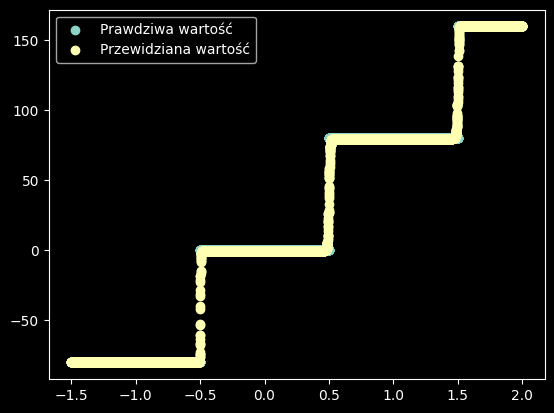

In [90]:
# Wyświetl jak wygląda predykcja modelu dla ostatniego kroku

plt.scatter(x_to_plot, y_to_plot)
plt.scatter(x_to_plot, y_pred_to_plot)
plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
plt.show()

In [91]:
# Przetestuj model na zbiorze testowym

test_x_to_plot = []
test_y_to_plot = []
test_y_pred_to_plot = []


x = torch.tensor(test_x_list).reshape(-1,1).to(device)
y = torch.tensor(test_y_list).reshape(-1,1).to(device)

if czy_znormalizowac:
  x_normalized = (x - x_min) / (x_max - x_min)
  y_normalized = (y - y_min) / (y_max - y_min)
else:
  x_normalized = x
  y_normalized = y

y_pred = model(x_normalized)

test_x_to_plot = test_x_to_plot + x.tolist()
test_y_to_plot = test_y_to_plot + y.tolist()
test_y_pred_to_plot = test_y_pred_to_plot + (y_pred*(y_max - y_min) + y_min).tolist()

loss = criterion(y_pred, y_normalized)

if czy_znormalizowac:
  print(f"Znormalizowana finalna wartość funkcji straty: {loss.item()}")
  normalized_loss = criterion( y_pred*(y_max - y_min) + y_min , y)
  print(f"Nieznormalizowana finalna wartość funkcji straty: {normalized_loss.item()}")
else:
  print(f"Nieznormalizowana finalna wartość funkcji straty: {loss.item()}")

Znormalizowana finalna wartość funkcji straty: 0.00012112854892620817
Nieznormalizowana finalna wartość funkcji straty: 6.977004051208496


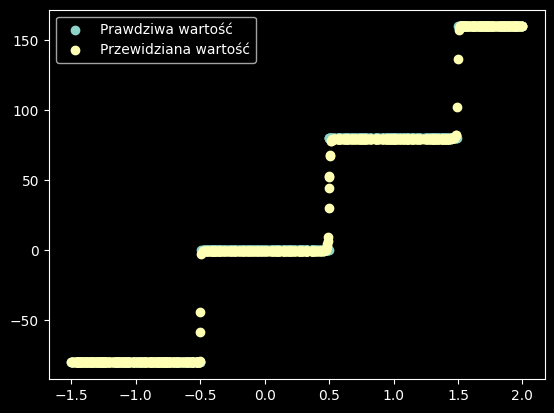

In [92]:
# Wyświetl prawdziwą wartość funkcji i przewidzianą wartość nieznormalizowaną

plt.scatter(test_x_to_plot, test_y_to_plot)
plt.scatter(test_x_to_plot, test_y_pred_to_plot)
plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
plt.show()

In [93]:
# Funkcja do wyciągania wag z warstw liniowych

def get_weights_and_bias(linear_layer):
    print(f"Waga: {linear_layer.weight.data.cpu().numpy()}")
    print(f"Bias: {linear_layer.bias.data}")

# Przykład wyciągniecia wag z pierwszej warstwy liniowej
layer = model[0]
get_weights_and_bias(layer)

Waga: [[ 746.5839   ]
 [-582.9855   ]
 [  -2.1919196]
 [   3.2751026]
 [1159.7727   ]]
Bias: tensor([-426.3555,  502.8300,   17.8853,   14.7611, -328.1114],
       device='cuda:0')


In [94]:
# Wyciągnij wagi ze wszystkich warstw liniowych i wklej je do swojego modelu w numpy.
# Uważaj na orientację wagi, być może trzeba będzie ją transponować!!! Pytorch może inaczej wymnażać X i weights niż wasz kod.

# Tu zrób kod
layer = model[2]
get_weights_and_bias(layer)

Waga: [[  1.3866621 -20.374657   -3.036112    3.9852638  19.355583 ]]
Bias: tensor([-0.6240], device='cuda:0')


In [95]:
# layer = model[4]
# get_weights_and_bias(layer)